# Checking the report's numbers and the closure effect (iteration-3 evaluation)

This notebook is a demo of `eval.py`, the assembly step of a read-only, CPU-only evaluation of five iteration-2 artifacts
(`art_eR1Z7fMlOcxs`, `art_BdBvbNuNU8E7`, `art_yjFB8Spw2w6M`, `art_mbFjmo5rbbf8`, `art_yWUkgWWKyq_h`). It costs $0 and uses no GPU.

`eval.py` runs three parts in dependency order and writes one `eval_out.json` (`exp_eval_sol_out` schema):

* **Part 1: numbers of record** (`part1_record.py`). Every number in the current report is traced back to a run-root-relative source file,
  with its estimator, `n`, CI and a **drift flag** (`OK`, `DRIFT_VALUE`, `WRONG_ESTIMATOR`, `WRONG_UNITS`, `WRONG_DEFINITION`, `NOT_REDERIVABLE`, ...).
  The full run finds 406 rows, 182 of them recomputed from item-level files, and 42 non-OK flags.
* **Part 2: R1a turnover pre-check** (`part2_r1a.py`). Does the E_up *closure* event-study effect survive after residualising closure
  on turnover (new-relation rate, novelty, Baselga beta_sim, volume, age, H)? It reports S_raw, S_res, the retained share,
  positive and negative controls and a placebo, plus IVW pooling of the main and MeSH populations.
  *This is a pre-check on already-screened data, not a confirmation.*
* **Part 3: decision rules (a)-(d)** (`part3_rules.py`). It also produces the aligned-block table, the held-out seal audit and the coverage table.

**What this demo runs.** Parts 1-3 read gigabytes of iteration-2 artifacts that are not shipped here. Each part's `main()` returns a
Python object, and `mini_demo_data.json` holds exactly those objects, precomputed by the full run:
`record_summary`, a curated 100 of the 406 `record_rows`, the `r1a` result dict and the `p3` rules, audit, aligned and coverage tables.
Everything after the three `main()` calls is the original `eval.py` code, cell by cell: the metric assembly, the six output datasets and
`eval_out.json`. A summary and plots follow at the end.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is NOT pre-installed on Colab: always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib are pre-installed on Colab: install locally only (at Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

## Imports
This is the original import block of `eval.py`. `import common as K` is replaced by a small inline namespace a few cells below.
`pandas`, `SimpleNamespace`, `Path` and `matplotlib` are added for the notebook.

In [2]:
from __future__ import annotations

import json
import math
import time

import numpy as np
from loguru import logger

# import common as K   # replaced by the inline `K` namespace below (common.py helpers used by eval.py)

# --- added for the notebook
import sys
from pathlib import Path
from types import SimpleNamespace
import pandas as pd
import matplotlib.pyplot as plt

## Data loading
The data is loaded from GitHub (for Colab). If that fails, a local `mini_demo_data.json` is used.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-3/evaluation-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: (len(v) if isinstance(v, (list, dict)) else v) for k, v in data.items() if k != "description"})

{'record_summary': 5, 'record_rows': 100, 'r1a': 8, 'p3': 4}


## Config
`eval.py` has no training loops or sampling parameters. The only size knob is how many numbers-of-record rows go into the
`numbers_of_record` output dataset. The original script uses all 406 rows. `mini_demo_data.json` ships a curated 100:
all 42 drift-flagged rows, every row `eval.py` reads by id, and rows from all 23 blocks. The aggregate counts
(`record_n_*`) always come from the full-run `record_summary`.

In [5]:
N_RECORD_ROWS = 100   # rows of the numbers-of-record table to process (mini data holds 100; original full run: 406)

## Shared helpers (from `common.py`)
This cell copies the parts of `common.py` that `eval.py` uses: the header string, the artifact ids, logging setup, JSON-safe
cleaning and `dump`. It puts them in a `K` namespace, so the original `K.xxx` calls work unchanged. `setup_logging` logs to stdout only,
and `WS` is the current directory.

In [6]:
HEADER = "PRE-CHECK ON ALREADY-SCREENED DATA; NOT CONFIRMATION; E_up promoted post hoc"
ART_IDS = {"exp_1": "art_BdBvbNuNU8E7", "exp_2": "art_yjFB8Spw2w6M", "exp_3": "art_mbFjmo5rbbf8",
           "exp_4": "art_yWUkgWWKyq_h", "dataset_5": "art_eR1Z7fMlOcxs"}


def setup_logging(name: str) -> None:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")


def clean(x):
    """JSON-safe conversion (NaN/inf -> None, numpy -> python)."""
    if isinstance(x, dict):
        return {str(k): clean(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [clean(v) for v in x]
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating, float)):
        v = float(x)
        return None if not math.isfinite(v) else v
    if isinstance(x, np.bool_):
        return bool(x)
    if isinstance(x, np.ndarray):
        return clean(x.tolist())
    return x


def dump(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(clean(obj), indent=1, allow_nan=False))


def load_json(p: Path):
    return json.loads(Path(p).read_text())


K = SimpleNamespace(HEADER=HEADER, ART_IDS=ART_IDS, setup_logging=setup_logging, clean=clean, dump=dump, load_json=load_json, WS=Path("."))

## Numeric helpers (original)
`num` turns a value into a finite float, or `None`. `evals` keeps only the finite numeric fields of a dict and prefixes them with
`eval_` (booleans become 0/1), as the `exp_eval_sol_out` schema requires numeric `eval_*` fields.

In [7]:
def num(x) -> float | None:
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if math.isfinite(v) else None


def evals(d: dict) -> dict:
    """eval_* fields must be numbers: keep finite numerics only (bools -> 0/1)."""
    out = {}
    for k, v in d.items():
        if isinstance(v, bool):
            out[f"eval_{k}"] = int(v)
        else:
            n = num(v)
            if n is not None:
                out[f"eval_{k}"] = n
    return out

## Run parts 2, 1, 3 (their returned objects are loaded from `data`)
In `eval.py` this is `r1a = part2_r1a.main()`, `rec_sum = part1_record.main()` and `p3 = part3_rules.main()`. Each call reads the
iteration-2 artifacts: matched sets, per-concept panels, prediction files and the report. Here the objects those calls **return** are
taken from `data`. `p3["aligned"]` and `p3["coverage"]` are pandas DataFrames in the original, so they are rebuilt as DataFrames.
The lookups that follow (`byid`, `ev`, `corr`, `rules`, `audit`, `rv`) are the original code.

In [8]:
K.setup_logging("eval")
t0 = time.time()
# import part1_record
# import part2_r1a
# import part3_rules
logger.info("PART 2 (R1a) ...")
r1a = data["r1a"]                      # original: part2_r1a.main()
logger.info("PART 1 (numbers of record) ...")
rec_sum = data["record_summary"]       # original: part1_record.main()
K.setup_logging("eval")
logger.info("PART 3 (rules and tables) ...")
p3 = dict(aligned=pd.DataFrame(data["p3"]["aligned"]), rules=data["p3"]["rules"], audit=data["p3"]["audit"],
          coverage=pd.DataFrame(data["p3"]["coverage"]))   # original: part3_rules.main()
K.setup_logging("eval")
rec = data["record_rows"][:N_RECORD_ROWS]   # original: K.load_json(K.RES / "record_of_numbers.json")["rows"]
byid = {r["id"]: r for r in rec}
ev = {(r["population"], r["spec"]): r for r in r1a["event"]}
corr = {(c["population"], c["pair"]): c for c in r1a["correlations"]}
rules = p3["rules"]
audit = p3["audit"]

def rv(i: str) -> float | None:
    return num(byid[i]["value"]) if i in byid else None

print(f"record rows: {len(rec)}, r1a event specs: {len(ev)}, correlations: {len(corr)}, aligned rows: {len(p3['aligned'])}")

20:50:26|INFO   |PART 2 (R1a) ...


20:50:26|INFO   |PART 1 (numbers of record) ...


20:50:26|INFO   |PART 3 (rules and tables) ...


record rows: 100, r1a event specs: 22, correlations: 13, aligned rows: 9


## Aggregate metrics: record counts and the classifier
The record-of-numbers counts come from Part 1's summary. The classifier rows are evaluated at the frozen threshold t_F1 = 0.5073:
precision, recall, accuracy, F1, AUC and kappa, plus the predict-all-positive baseline F1 and the differences from LLM-A and LLM-B.
The logit and HGB delta-AUCs for E_up are included too. `rv(id)` returns `None` when the id is not among the loaded rows. Such metrics are dropped later.

In [9]:
m = dict(record_n_rows=rec_sum["n_rows"], record_n_recomputed=rec_sum["n_recomputed"], record_n_not_rederivable=rec_sum["n_not_rederivable"],
         record_n_flags=rec_sum["n_flags"])
for f, c in rec_sum["n_flags_by_type"].items():
    m[f"record_n_flag_{f}"] = c
m.update(classifier_precision=rv("B1.clf.tF1.precision"), classifier_recall=rv("B1.clf.tF1.recall"), classifier_accuracy=rv("B1.clf.tF1.accuracy"),
         classifier_f1=rv("B1.clf.tF1.f1"), classifier_auc=rv("B1.clf.auc"), classifier_kappa=rv("B1.clf.tF1.kappa"),
         majority_all_positive_f1=rv("B1.base.all_positive_f1"), classifier_f1_minus_all_positive=rv("B1.clf.delta_f1_vs_allpos"),
         classifier_minus_llmA_f1=rv("B1.clf_minus_llmA.f1"), classifier_minus_llmB_f1=rv("B1.clf_minus_llmB.f1"),
         main_E_up_logit_delta_auc=rv("B3.E_up.logit.delta_auc"), main_E_up_hgb_delta_auc=rv("B3.E_up.hgb.delta_auc"))

## Aggregate metrics: R1a per population (main, MeSH)
For each population, spec `P` (the primary residualisation) gives the raw event-study closure effect `S_raw`, its complete-case
version `S_raw_cc`, the residualised effect `S_res` with its CI, the `retained` share (`S_res / S_raw_cc`), the MDE, the reproduction gate
and the verdict flags. It also records the volume-only (`V0`) and rarefied-Baselga (`R`) retained shares, the controls
(noise `NEG`, `POS_ORACLE`, `POS`), and the within-concept correlations of closure with each turnover measure.

In [10]:
for pop in ("main", "mesh"):
    r = ev[(pop, "P")]
    m.update({f"{pop}_S_raw": r["S_raw"], f"{pop}_S_raw_cc": r["S_raw_cc"], f"{pop}_S_res": r["S_res"], f"{pop}_S_res_ci_lo": r["S_res_ci"][0],
              f"{pop}_S_res_ci_hi": r["S_res_ci"][1], f"{pop}_S_fit": r["S_fit"], f"{pop}_retained": r["retained"],
              f"{pop}_retained_ci_lo": r["retained_ci"][0], f"{pop}_retained_ci_hi": r["retained_ci"][1], f"{pop}_mde_res_sd": r["mde_res_in_sd"],
              f"{pop}_n_treated_res": r["n_treated_res"], f"{pop}_gate_S_exact": int(r1a["gate"][pop]["S_exact"]),
              f"{pop}_gate_passed": int(r1a["gate"][pop]["passed"]),
              f"{pop}_verdict_not_reducible": int(r1a["verdicts"][pop]["verdict"].startswith("NOT REDUCIBLE")),
              f"{pop}_verdict_largely_turnover": int(r1a["verdicts"][pop]["verdict"].startswith("LARGELY")),
              f"{pop}_retained_volume_only_V0": ev[(pop, "V0")]["retained"], f"{pop}_retained_spec_R_rarefied": ev[(pop, "R")]["retained"],
              f"{pop}_neg_control_retained_vs_V0": r1a["controls"][pop]["NEG"]["retained_vs_V0"],
              f"{pop}_pos_oracle_retained": r1a["controls"][pop]["POS_ORACLE"]["retained"],
              f"{pop}_pos_closure_raw_retained": r1a["controls"][pop]["POS"]["retained"]})
    for key in ("new_rel", "novelty", "beta_sim", "beta_sim_rar"):
        c = corr[(pop, f"closure~{key}")]
        m[f"{pop}_r_within_closure_{key}"] = c.get("r_within")
        m[f"{pop}_r_within_closure_{key}_ci_lo"] = c.get("r_within_ci", [None, None])[0]
        m[f"{pop}_r_within_closure_{key}_ci_hi"] = c.get("r_within_ci", [None, None])[1]

## Aggregate metrics: IVW pooling, rules, held-out audit, tables
This cell adds fixed-effect IVW pooling of main and MeSH (with Cochran Q and I^2; Q is underpowered at k = 2), the pooled verdict,
the placebo, the four decision-rule outcomes, the held-out seal audit counts and the aligned-block and coverage table counts.
It then keeps only the finite numeric values in `metrics`.

In [11]:
pr = r1a["pooling"]
m.update(ivw_S_res=pr["P"]["res"]["S_ivw"], ivw_se_res=pr["P"]["res"]["se_ivw"], ivw_S_res_ci_lo=pr["P"]["res"]["ci"][0],
         ivw_S_res_ci_hi=pr["P"]["res"]["ci"][1], Q_res=pr["P"]["res"]["Q"], p_Q_res=pr["P"]["res"]["p_Q"], I2_res=pr["P"]["res"]["I2"],
         ivw_S_raw_cc=pr["P"]["raw_cc"]["S_ivw"], Q_raw_cc=pr["P"]["raw_cc"]["Q"], ivw_S_raw_recorded=pr["raw_recorded_files"]["S_ivw"],
         Q_raw_recorded=pr["raw_recorded_files"]["Q"], pooled_retained=pr["pooled_verdict"]["retained"],
         pooled_retained_ci_lo=pr["pooled_verdict"]["retained_ci"][0], pooled_retained_ci_hi=pr["pooled_verdict"]["retained_ci"][1],
         main_placebo_S_res=r1a["controls"]["main"]["PLACEBO"]["S_res"],
         rule_a_triggered=int(rules["a"]["triggered"]), rule_b_pilot_only=int(rules["b"]["pilot_only"]), rule_c_met=int(rules["c"]["met"]),
         rule_d_sealed=int(rules["d"]["sealed"]), heldout_id_hits_exp3_exp4=audit["hits_exp3_exp4_total"],
         heldout_files_scanned=audit["files_scanned_exp3_exp4"], heldout_ids_dataset5=audit["id_sets"]["n_heldout_dataset5"],
         heldout_iter1_subset=int(audit["id_sets"]["iter1_subset_of_dataset5"]),
         aligned_n_interpretable=int(p3["aligned"].interpretable.sum()), aligned_n_file_reproduced=int(p3["aligned"].ivw_agrees_file.sum()),
         coverage_n_done=int((p3["coverage"].status == "done").sum()), coverage_n_partial=int((p3["coverage"].status == "partial").sum()),
         coverage_n_planned=int((p3["coverage"].status == "planned").sum()), runtime_s=time.time() - t0)
metrics = {k: float(v) for k, v in m.items() if num(v) is not None}
print(f"{len(metrics)} metrics")

117 metrics


## Dataset 1: numbers of record
Each record row becomes one example. The input is the claim. The output is the recomputed value, or the file hash for hash rows.
The predicted value is the one the report states, and the drift flag and provenance go in the metadata.

In [12]:
# ---------------- datasets
ds_rec = []
for r in rec:
    ex = {"input": r["claim"], "output": "" if r["value"] is None else f"{r['value']:.6g}",
          "metadata_id": r["id"], "metadata_block": r["block"], "metadata_flag": r["flag"], "metadata_unit": r["unit"],
          "metadata_estimator": r["estimator"], "metadata_source_path": r["source_path"], "metadata_source_key": r["source_key"],
          "metadata_recomputed": r["recomputed"], "metadata_recompute_method": r["recompute_method"], "metadata_note": r["note"],
          "metadata_report_line": r["report_line"], "predict_report_value": "" if r["report_value"] is None else f"{r['report_value']:g}"}
    if r.get("hash_hex"):
        ex["output"] = r["hash_hex"]
        ex["metadata_hash_match"] = r.get("hash_match")
    ex.update(evals(dict(value=r["value"], ci_lo=r["ci_lo"], ci_hi=r["ci_hi"], n=r["n"], report_value=r["report_value"],
                         agrees=r["agrees"] if r["agrees"] is not None else None, flag_ok=r["flag"] in ("OK", "MISSING_IN_REPORT"))))
    ds_rec.append(ex)

## Datasets 2-3: R1a event-study results and within-concept correlations
There is one example per population and residualisation spec, with the applied verdict rule as output. There is also one per
closure-turnover correlation pair, with its within-concept r and CI.

In [13]:
ds_r1a = []
for r in r1a["event"]:
    ex = {"input": f"R1a event study E_up closure, population={r['population']}, residualisation spec={r['spec']} ({K.HEADER})",
          "output": r["verdict_rule_applied"], "metadata_population": r["population"], "metadata_spec": r["spec"],
          "metadata_diff_k_raw": r["diff_k_raw"], "metadata_diff_k_res": r["diff_k_res"], "metadata_header": K.HEADER}
    ex.update(evals({k: r[k] for k in ("S_raw", "S_raw_cc", "S_res", "S_res_se", "S_res_p", "S_fit", "retained", "mde_res", "mde_res_in_sd",
                                       "n_treated_raw", "n_treated_res", "treated_lost", "retained_boot_dropped")}))
    ex.update(evals(dict(S_res_ci_lo=r["S_res_ci"][0], S_res_ci_hi=r["S_res_ci"][1], retained_ci_lo=r["retained_ci"][0],
                         retained_ci_hi=r["retained_ci"][1], S_fit_ci_lo=r["S_fit_ci"][0], S_fit_ci_hi=r["S_fit_ci"][1])))
    ds_r1a.append(ex)
ds_corr = []
for c in r1a["correlations"]:
    if "r_within" not in c:
        continue
    ex = {"input": f"Within-concept correlation {c['pair']} ({c['x']} vs {c['y']}), population={c['population']}",
          "output": f"{c['r_within']:.3f} [{c['r_within_ci'][0]:.3f}, {c['r_within_ci'][1]:.3f}]", "metadata_role": c["role"]}
    ex.update(evals(dict(r_within=c["r_within"], r_within_ci_lo=c["r_within_ci"][0], r_within_ci_hi=c["r_within_ci"][1],
                         rho_within=c["rho_within"], r_pooled=c["r_pooled"], n_concepts=c["n_concepts"], n_rows=c["n_rows"])))
    ds_corr.append(ex)

## Datasets 4-6: aligned block, decision rules, coverage
* **Aligned block**: MeSH vs main S for each label and indicator, with IVW and Q (SE = CI width / 3.92) and whether the row is interpretable.
* **Decision rules (a)-(d)**: the verbatim rule text, the verdict, and rule-specific numbers (Gate A share, graft events, N_c, MDE, held-out hits).
* **Coverage**: one row per research question or item: done, partial or planned.

In [14]:
ds_al = []
for r in p3["aligned"].to_dict("records"):
    ex = {"input": f"Aligned block {r['label']} x {r['indicator']}: MeSH vs main S, IVW and Q",
          "output": f"S_mesh {r['S_mesh']:.3f}, S_main {r['S_main']:.3f}, IVW {r['S_ivw_ciwidth_se']:.3f}, Q {r['Q_ciwidth_se']:.2f}, "
                    f"interpretable={r['interpretable']}", "metadata_note": r["note"]}
    ex.update(evals({k: v for k, v in r.items() if k not in ("label", "indicator", "note")}))
    ds_al.append(ex)
ds_rules = []
for k in "abcd":
    rr = rules[k]
    ex = {"input": f"Decision rule ({k}): {rr.get('text') or rr.get('condition')}", "output": rr["verdict"],
          "metadata_text_status": rr["text_status"], "metadata_source": rr["source"]}
    flag = {"a": rr.get("triggered"), "b": rr.get("pilot_only"), "c": rr.get("met"), "d": rr.get("sealed")}[k]
    ex["eval_rule_outcome"] = int(bool(flag))
    if k == "a":
        ex.update(evals(dict(gate_a_share=rr["value"], graft_events_total=rr["graft_events"]["total"], graft_events_kw5=rr["graft_events"]["kw5"])))
    if k == "b":
        ex.update(evals(dict(realised_N_c=rr["realised_N_c"], mde_delta_auc_070=rr["mde_delta_auc_base070"], mde_delta_auc_080=rr["mde_delta_auc_base080"])))
    if k == "c":
        ex["metadata_per_precursor"] = rr["per_precursor"]
        ex.update(evals(dict(n_precursor_rows_all_met=sum(c["all_met"] for c in rr["per_precursor"]))))
    if k == "d":
        ex.update(evals(dict(hits_exp3_exp4=rr["hits_exp3_exp4"], files_scanned=rr["files_scanned"])))
        ex["metadata_exp2_caveat"] = rr["exp2_caveat"]
    ds_rules.append(ex)
ds_cov = []
for r in p3["coverage"].to_dict("records"):
    ds_cov.append({"input": f"Coverage of {r['item']}", "output": r["status"], "metadata_evidence": r["evidence"], "metadata_gap": r["gap"],
                   "metadata_scheduled": r["scheduled"], "eval_status_score": {"done": 1.0, "partial": 0.5, "planned": 0.0}[r["status"]]})

## Assemble and write `eval_out.json`
This is the original output assembly: metadata (header, inputs, R1a spec hash, verdicts, rule verdicts, flag counts, notes),
`metrics_agg` and the six datasets. It is written to `./eval_out.json`.

In [15]:
out = {
    "metadata": {
        "evaluation_name": "Fix the record and test closure vs turnover (iteration 3, gen_art_evaluation_1)",
        "description": "Part 1 numbers of record with drift flags vs iter_3/gen_strat/current_report.md; Part 2 R1a turnover pre-check on the two "
                       "already-screened populations; Part 3 decision rules (a)-(d), aligned-block table, held-out seal audit, coverage.",
        "header": K.HEADER,
        "inputs": {k: v for k, v in K.ART_IDS.items()},
        "r1a_spec_sha256": r1a["spec_sha256"],
        "r1a_verdicts": {k: v["verdict"] for k, v in r1a["verdicts"].items()},
        "rules": {k: rules[k]["verdict"] for k in "abcd"},
        "record_flag_counts": rec_sum["n_flags_by_type"],
        "notes": ["All paths are relative to the run root.", "Q is underpowered at k = 2; it is not a test of agreement.",
                  "MeSH reproduction gate: S exact, CI off by 0.025 because exp_4's shared RNG stream cannot be replayed (recorded CI lies inside the "
                  "30-seed Monte-Carlo range).", "Deviation D1: MeSH SPEC P uses beta_sim_raw (the column computed with the main-pool code); "
                  "plan-literal beta_sim is sensitivity B_native."],
    },
    "metrics_agg": metrics,
    "datasets": [dict(dataset="numbers_of_record", examples=ds_rec), dict(dataset="r1a_results", examples=ds_r1a),
                 dict(dataset="r1a_within_concept_correlations", examples=ds_corr), dict(dataset="aligned_block", examples=ds_al),
                 dict(dataset="decision_rules", examples=ds_rules), dict(dataset="coverage", examples=ds_cov)],
}
K.dump(out, K.WS / "eval_out.json")
logger.info(f"eval_out.json written: {len(metrics)} metrics, datasets {[len(d['examples']) for d in out['datasets']]}, {time.time() - t0:.0f}s")

20:50:26|INFO   |eval_out.json written: 117 metrics, datasets [100, 22, 13, 9, 4, 8], 0s


## Results summary and visualisation
The tables below show the headline metrics, the R1a verdicts and the rule verdicts. The plots show:
(1) drift-flag counts in the report audit, (2) raw vs residualised E_up closure effects with 95% CIs for main, MeSH and IVW pooled,
(3) the share of the closure effect retained under each residualisation spec and control, and (4) within-concept correlations
of closure with each turnover measure.

                         metric   value
           classifier_precision  0.7590
              classifier_recall  0.8862
                  classifier_f1  0.8177
                 classifier_auc  0.8879
       majority_all_positive_f1  0.7152
      main_E_up_logit_delta_auc -0.0104
                  main_S_raw_cc -0.7577
                     main_S_res -0.5655
                  main_retained  0.7464
                  mesh_S_raw_cc -0.1556
                     mesh_S_res -0.0940
                  mesh_retained  0.6039
                      ivw_S_res -0.1859
                          Q_res  1.8812
                        p_Q_res  0.1702
                         I2_res  0.4684
   main_retained_volume_only_V0  0.8714
  main_retained_spec_R_rarefied  1.0473
       main_pos_oracle_retained  0.0156
main_neg_control_retained_vs_V0  1.0012
             main_placebo_S_res  0.0064
               rule_a_triggered  1.0000
              rule_b_pilot_only  1.0000
                     rule_c_met  0.0000


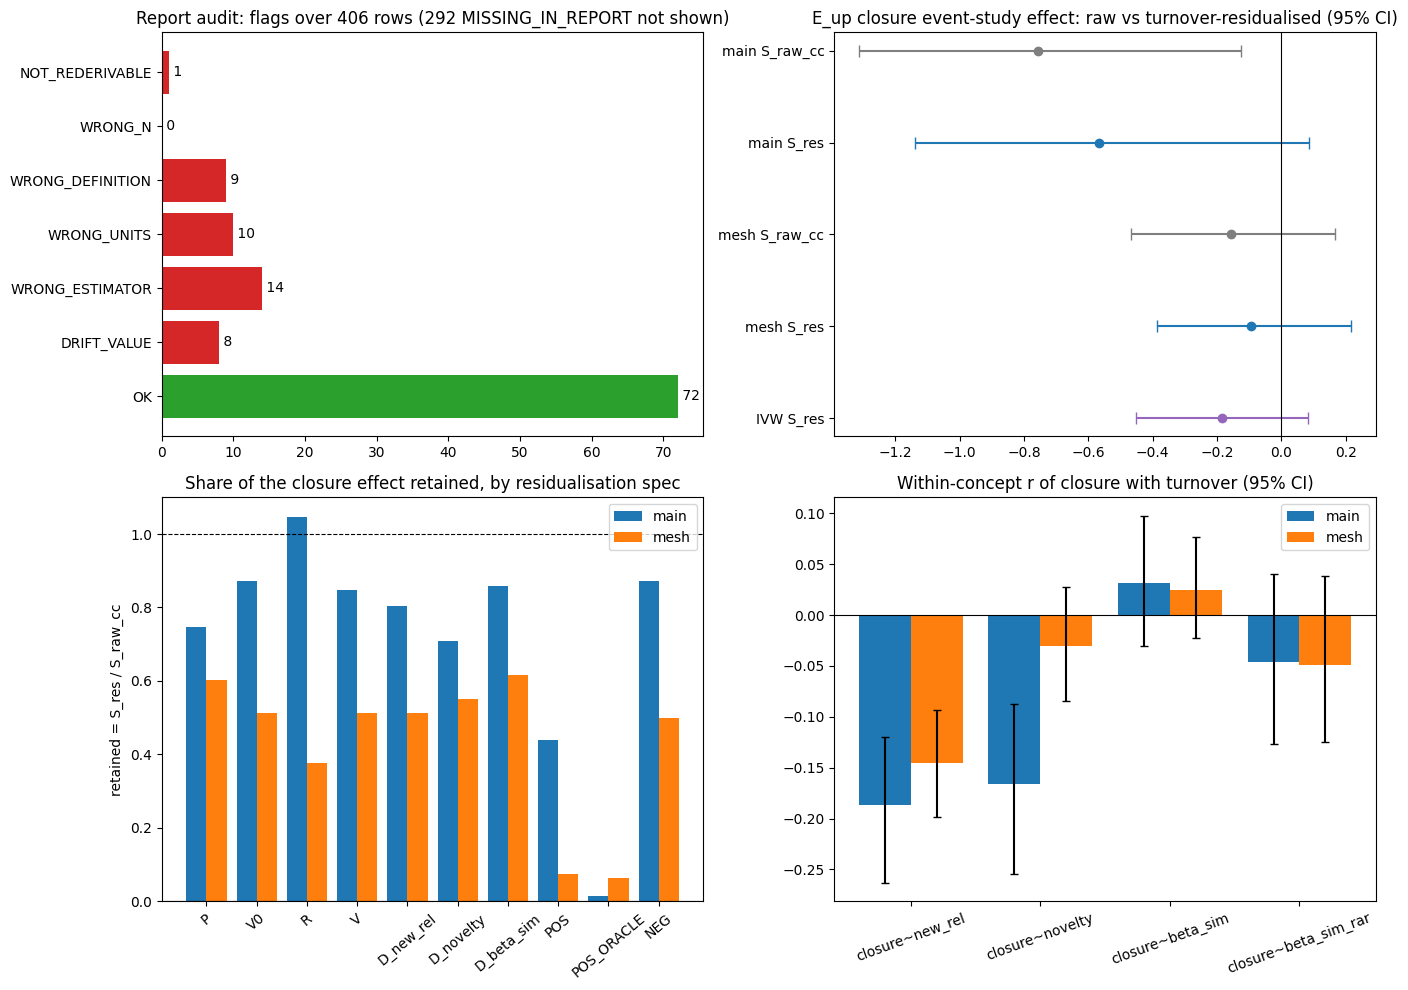

In [16]:
key = ["classifier_precision", "classifier_recall", "classifier_f1", "classifier_auc", "majority_all_positive_f1",
       "main_E_up_logit_delta_auc", "main_S_raw_cc", "main_S_res", "main_retained", "mesh_S_raw_cc", "mesh_S_res", "mesh_retained",
       "ivw_S_res", "Q_res", "p_Q_res", "I2_res", "main_retained_volume_only_V0", "main_retained_spec_R_rarefied",
       "main_pos_oracle_retained", "main_neg_control_retained_vs_V0", "main_placebo_S_res",
       "rule_a_triggered", "rule_b_pilot_only", "rule_c_met", "rule_d_sealed", "heldout_id_hits_exp3_exp4"]
print(pd.DataFrame([(k, metrics.get(k)) for k in key], columns=["metric", "value"]).to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nR1a verdicts:", out["metadata"]["r1a_verdicts"])
for k, v in out["metadata"]["rules"].items():
    print(f"rule ({k}): {v[:110]}")
print("\nDataset sizes:", {d["dataset"]: len(d["examples"]) for d in out["datasets"]})

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
# (1) drift flags
fc = {k: v for k, v in rec_sum["n_flags_by_type"].items() if k not in ("MISSING_IN_REPORT",)}
ax[0, 0].barh(list(fc), list(fc.values()), color=["tab:green" if k == "OK" else "tab:red" for k in fc])
ax[0, 0].set_title(f"Report audit: flags over {rec_sum['n_rows']} rows ({rec_sum['n_flags_by_type']['MISSING_IN_REPORT']} MISSING_IN_REPORT not shown)")
for i, v in enumerate(fc.values()):
    ax[0, 0].text(v, i, f" {v}", va="center")
# (2) raw vs residualised closure effect
labs, ys, lo, hi, cols = [], [], [], [], []
for pop in ("main", "mesh"):
    r = ev[(pop, "P")]
    for nm, s, ci, c in (("S_raw_cc", r["S_raw_cc"], r["S_raw_cc_ci"], "tab:gray"), ("S_res", r["S_res"], r["S_res_ci"], "tab:blue")):
        labs.append(f"{pop} {nm}"); ys.append(s); lo.append(ci[0]); hi.append(ci[1]); cols.append(c)
pv = pr["P"]["res"]
labs.append("IVW S_res"); ys.append(pv["S_ivw"]); lo.append(pv["ci"][0]); hi.append(pv["ci"][1]); cols.append("tab:purple")
yy = np.arange(len(labs))[::-1]
for y_, s, l, h, c in zip(yy, ys, lo, hi, cols):
    ax[0, 1].errorbar(s, y_, xerr=[[s - l], [h - s]], fmt="o", color=c, capsize=4)
ax[0, 1].axvline(0, color="k", lw=0.8)
ax[0, 1].set_yticks(yy); ax[0, 1].set_yticklabels(labs)
ax[0, 1].set_title("E_up closure event-study effect: raw vs turnover-residualised (95% CI)")
# (3) retained share by spec
specs = ["P", "V0", "R", "V", "D_new_rel", "D_novelty", "D_beta_sim", "POS", "POS_ORACLE", "NEG"]
w = 0.4
for j, pop in enumerate(("main", "mesh")):
    vals = [ev[(pop, s)]["retained"] if (pop, s) in ev and ev[(pop, s)]["retained"] is not None else np.nan for s in specs]
    ax[1, 0].bar(np.arange(len(specs)) + (j - 0.5) * w, vals, w, label=pop)
ax[1, 0].axhline(1, color="k", lw=0.8, ls="--"); ax[1, 0].axhline(0, color="k", lw=0.8)
ax[1, 0].set_xticks(range(len(specs))); ax[1, 0].set_xticklabels(specs, rotation=40)
ax[1, 0].set_ylabel("retained = S_res / S_raw_cc"); ax[1, 0].legend(); ax[1, 0].set_title("Share of the closure effect retained, by residualisation spec")
# (4) within-concept correlations
keys = ["new_rel", "novelty", "beta_sim", "beta_sim_rar"]
for j, pop in enumerate(("main", "mesh")):
    r_ = [metrics.get(f"{pop}_r_within_closure_{k}", np.nan) for k in keys]
    l_ = [metrics.get(f"{pop}_r_within_closure_{k}_ci_lo", np.nan) for k in keys]
    h_ = [metrics.get(f"{pop}_r_within_closure_{k}_ci_hi", np.nan) for k in keys]
    x_ = np.arange(len(keys)) + (j - 0.5) * w
    ax[1, 1].bar(x_, r_, w, label=pop, yerr=[np.array(r_) - np.array(l_), np.array(h_) - np.array(r_)], capsize=3)
ax[1, 1].axhline(0, color="k", lw=0.8)
ax[1, 1].set_xticks(range(len(keys))); ax[1, 1].set_xticklabels([f"closure~{k}" for k in keys], rotation=20)
ax[1, 1].legend(); ax[1, 1].set_title("Within-concept r of closure with turnover (95% CI)")
plt.tight_layout(); plt.show()